# Thesis: final checks on tweets, lyrics and emotion profiles

This follow-up notebook answers four questions using **completed seven-category Colab results**:

1. Is the tweet–lyric relationship stronger in the depression-labelled group than in controls?
2. Do the results persist after removing known music-sharing tweets?
3. How much do the number of tweets and shared songs influence the findings?
4. Which participants does the classifier miss or incorrectly flag?

## 1. Install the analysis packages


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'numpy==2.1.3', 'pandas==2.2.3', 'scipy==1.16.3', 'scikit-learn==1.6.1',
    'matplotlib>=3.8,<4', 'statsmodels>=0.14,<1', 'tqdm'])


0

## 2. Connect Drive or upload the companion ZIP


In [2]:
from google.colab import drive, files
from pathlib import Path

STORAGE_MODE = 'auto'  # 'auto', 'drive', or 'upload'
assert STORAGE_MODE in ['auto', 'drive', 'upload']
DRIVE_AVAILABLE = False
if STORAGE_MODE != 'upload':
    try:
        if not Path('/content/drive/MyDrive').is_dir():
            drive.mount('/content/drive', force_remount=True, timeout_ms=180000)
        DRIVE_AVAILABLE = Path('/content/drive/MyDrive').is_dir()
        if not DRIVE_AVAILABLE:
            raise ValueError('Drive did not expose MyDrive.')
    except Exception as exc:
        if STORAGE_MODE == 'drive':
            raise RuntimeError("Drive failed. Set STORAGE_MODE='upload' and rerun this cell.") from exc
        print('Drive unavailable:', type(exc).__name__, str(exc))
        print('Using direct upload and temporary storage.')

INPUT_ZIP = (Path('/content/drive/MyDrive') if DRIVE_AVAILABLE else Path('/content')) / 'Thesis_Final_Checks_inputs.zip'
PROJECT = (Path('/content/drive/MyDrive') if DRIVE_AVAILABLE else Path('/content')) / 'Thesis_Final_Checks'
if not INPUT_ZIP.is_file():
    print('Select only Thesis_Final_Checks_inputs.zip from your computer.')
    uploaded = files.upload(target_dir='/content')
    candidates = [Path(name) for name in uploaded if str(name).lower().endswith('.zip')]
    if len(candidates) != 1:
        raise ValueError('Select one companion ZIP, then rerun this cell.')
    INPUT_ZIP = candidates[0]
    if not INPUT_ZIP.is_absolute():
        INPUT_ZIP = Path('/content') / INPUT_ZIP
    del uploaded
    assert INPUT_ZIP.is_file(), 'Uploaded ZIP could not be located.'

BOOTSTRAPS = 2000
INCLUDE_RANDOM_FOREST = True
MIN_TWEETS = 100
MIN_SONGS = 3
SEED = 42
CODE_VERSION = 'thesis-final-checks-v1'
INPUT = Path('/content/thesis_final_check_inputs/final_check_inputs')
CACHE = PROJECT / 'cache'
RESULTS = PROJECT / 'results'
for path in [PROJECT, CACHE, RESULTS, RESULTS/'analysis', RESULTS/'figures']:
    path.mkdir(parents=True, exist_ok=True)
print('New results:', RESULTS)
if not DRIVE_AVAILABLE:
    print('Temporary storage: download the final ZIP before ending the runtime.')


Mounted at /content/drive
New results: /content/drive/MyDrive/Thesis_Final_Checks/results


## 3. Verify inputs, participants, model parameters and folds
All companion files are checked against their SHA-256 manifest. The original result files are also checked against their own output hashes. The supplied music-post subset was selected by exact released tweet IDs from **all original song-table rows**, including records later rejected for lyric quality. Its five original source embedding files were verified during packaging.

Only eligible non-diagnosis, non-retweet posts from the existing paired participants are included in that subset. A file audit records its original row positions and provenance. Raw tweet and lyric text are not included.


In [ ]:
import hashlib, importlib.metadata, json, platform, shutil, time, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import softmax
from scipy.stats import rankdata, spearmanr, mannwhitneyu
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, balanced_accuracy_score,
                             confusion_matrix, precision_recall_curve)
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm
from IPython.display import display, Markdown

LABELS = ['anger','disgust','fear','joy','neutral','sadness','surprise']
TCOLS = ['tweet_emotion_' + label for label in LABELS]
LCOLS = ['lyric_emotion_' + label for label in LABELS]
VADCOLS = [source + '_' + d for source in ['tweet','lyric'] for d in ['V','A','D']]
PAIRS = [(label, tc, lc) for label, tc, lc in zip(LABELS, TCOLS, LCOLS)] + [
    (name, 'tweet_' + d, 'lyric_' + d) for name,d in [('valence','V'),('arousal','A'),('dominance','D')]]
PACKAGE_VERSIONS = {p: importlib.metadata.version(p) for p in
                    ['numpy','pandas','scipy','scikit-learn','matplotlib','statsmodels']}
assert np.__version__ == PACKAGE_VERSIONS['numpy'], 'Restart the runtime: imported NumPy differs from the installed package.'
assert pd.__version__ == PACKAGE_VERSIONS['pandas'], 'Restart the runtime: imported pandas differs from the installed package.'

def sha256(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

def write_json(path, content):
    path = Path(path); partial = path.with_name(path.name + '.partial')
    partial.write_text(json.dumps(content, indent=2, allow_nan=False))
    partial.replace(path)

def save_npz(path, **arrays):
    path = Path(path); partial = path.with_name(path.name + '.partial')
    with partial.open('wb') as stream:
        np.savez_compressed(stream, **arrays)
    partial.replace(path)

def save_figure(fig, name):
    fig.savefig(RESULTS/'figures'/(name+'.png'), dpi=180, bbox_inches='tight')
    fig.savefig(RESULTS/'figures'/(name+'.pdf'), bbox_inches='tight')
    plt.show()
    plt.close(fig)

INPUT.parent.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(INPUT_ZIP) as z:
    for info in z.infolist():
        assert (INPUT.parent/info.filename).resolve().is_relative_to(INPUT.parent.resolve()), 'Unsafe ZIP member.'
    assert z.testzip() is None, 'ZIP corruption detected.'
    z.extractall(INPUT.parent)
input_manifest = json.loads((INPUT/'INPUT_MANIFEST.json').read_text())

assert input_manifest['bundle_version'] == 'final-check-inputs-v1'

for name, info in tqdm(input_manifest['files'].items(), desc='Verifying inputs'):
    path = INPUT/name
    assert path.stat().st_size == info['bytes'] and sha256(path) == info['sha256'], name

old_hashes = json.loads((INPUT/'results/OUTPUT_HASHES.json').read_text())
assert all(sha256(INPUT/'results'/name) == expected for name,expected in old_hashes.items())
features = pd.read_csv(INPUT/'results/analysis/participant_features.csv', dtype={'participant_id': str})
folds = pd.read_csv(INPUT/'support/fold_assignments.csv', dtype={'participant_id': str})
old_oof = pd.read_csv(INPUT/'results/analysis/classification_oof.csv', dtype={'participant_id': str})
old_summary = pd.read_csv(INPUT/'results/analysis/classification_summary.csv')
source_manifest = json.loads((INPUT/'results/model/manifest.json').read_text())
subset_audit = json.loads((INPUT/'support/subset_audit.json').read_text())
assert len(features) == 4256 and features.participant_id.is_unique
assert features.disorder.value_counts().to_dict() == {'control': 3502, 'depression': 754}
assert features.participant_id.tolist() == folds.participant_id.tolist()
assert features.disorder.tolist() == folds.disorder.tolist()
assert set(folds.fold) == set(range(1,6))
assert np.isfinite(features[VADCOLS+TCOLS+LCOLS].to_numpy()).all()
assert int(features.tweet_count.sum()) == 6345978 and int(features.song_count.sum()) == 47204
assert np.allclose(features[TCOLS].sum(axis=1), 1, atol=1e-10)
assert np.allclose(features[LCOLS].sum(axis=1), 1, atol=1e-10)
features['log_tweet_count'] = np.log1p(features.tweet_count)
features['log_song_count'] = np.log1p(features.song_count)
features['fold'] = folds.fold.to_numpy()
y_original = features.disorder.eq('depression').astype(int).to_numpy()

for (name,model), group in old_oof.groupby(['features','model']):
    ordered = group.set_index('participant_id').loc[features.participant_id]
    assert len(group) == 4256 and group.participant_id.is_unique
    assert np.array_equal(ordered.y, y_original) and np.array_equal(ordered.fold, features.fold)
    assert np.isfinite(ordered.probability).all() and ordered.probability.between(0,1).all()
    assert set(ordered.predicted).issubset({0,1})
    assert np.array_equal(ordered.predicted, ordered.probability.gt(.5).astype(int))
    previous = old_summary[(old_summary.features==name)&(old_summary.model==model)].iloc[0]
    assert abs(roc_auc_score(ordered.y, ordered.probability)-previous.pooled_auroc) < 1e-12

emotion = np.load(INPUT/'results/model/emotion_logistic.npz', allow_pickle=False)

COEF, INTERCEPT = emotion['coef'], emotion['intercept']
assert emotion['labels'].tolist() == LABELS and COEF.shape == (7,384) and INTERCEPT.shape == (7,)
fingerprint = hashlib.sha256(COEF.tobytes()+INTERCEPT.tobytes()+json.dumps(
    {'labels': LABELS, 'C': float(emotion['C'])}, sort_keys=True).encode()).hexdigest()
assert fingerprint == source_manifest['model_sha256'], 'Emotion model fingerprint mismatch.'

display(features.groupby('disorder')[['tweet_count','song_count']].agg(['count','median','mean']))
print('Verified original participants, VAD/category values, predictions, model and folds.')


Verifying inputs:   0%|          | 0/44 [00:00<?, ?it/s]

tweet_count                      song_count                  
                 count  median         mean      count median       mean
disorder                                                                
control           3502  1595.0  1427.924615       3502    3.0  11.633067
depression         754  1998.0  1784.331565        754    3.0   8.574271

Verified original participants, VAD/category values, predictions, model and folds.


## 4. Record the exploratory follow-up plan
The ten primary correlation-difference tests form **one BH false-discovery-rate family**: seven matching categories plus three matching VAD dimensions. Bootstrap participants independently within each group while keeping each participant's tweet/lyric pair together. Basic bootstrap intervals and approximate, centred-bootstrap two-sided p-values assess the depression-minus-control correlation difference. This avoids assuming that the two groups have identical marginal score distributions.

Other robustness summaries and paired prediction intervals are descriptive/exploratory, with no further confirmatory significance claims. All intervals are pointwise unless stated otherwise. Changing settings requires a new project folder so cached runs cannot silently mix.


In [ ]:
assert BOOTSTRAPS >= 2000 and MIN_TWEETS == 100 and MIN_SONGS == 3

plan = {
    'code_version': CODE_VERSION,
    'scope': 'Exploratory follow-up after primary VAD and categorical results; not externally preregistered.',
    'input_zip_sha256': sha256(INPUT_ZIP), 'source_model_fingerprint': fingerprint,
    'bootstrap_replicates': BOOTSTRAPS, 'include_random_forest': INCLUDE_RANDOM_FOREST,
    'classifier_seed': SEED, 'correlation_bootstrap_seed_base':20261020,
    'prediction_summary_bootstrap_seed_base':20261100, 'paired_bootstrap_seed_base':20261200,
    'minimum_tweets': MIN_TWEETS, 'minimum_songs': MIN_SONGS,
    'primary_test_family': 'Ten depression-minus-control matching Spearman differences; centred-bootstrap approximate p-values; BH across all ten.',
    'intervals': 'Basic group-difference bootstrap CIs; percentile paired OOF AUROC CIs. Conditional on supplied participants/predictions; no shared-song clustering or full retraining uncertainty.',
    'music_exclusion': 'All known sharing-post IDs, including rejected-lyric records; fixed emotion/VAD models; subtract scored posts from participant means.',
    'activity': 'Partial rank correlations controlling tweet/song counts (and group in pooled analysis); separately restrict to >=100 tweets and >=3 songs; add log1p counts as classifier features.',
    'classifiers': 'Original fixed five participant folds; LR C=1, balanced, train-fold imputation/scaling; RF 300 trees, leaf3, balanced_subsample; no tuning.',
    'classification_threshold': 'Original default 0.5 only. No held-out threshold selection or clinical risk calibration.',
    'further_inference': 'Sensitivity correlations/group effects and paired predictive intervals are exploratory; paired intervals are not multiplicity-adjusted.',
    'packages': PACKAGE_VERSIONS,
}
plan_path = RESULTS/'analysis/followup_plan.json'

if plan_path.exists():
    previous = json.loads(plan_path.read_text())
    assert {k:v for k,v in previous.items() if k!='recorded_at_utc'} == plan, 'Settings changed: use a new PROJECT folder.'
else:
    write_json(plan_path, dict(plan, recorded_at_utc=time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime())))

CHECK_STATUS = {}

print('Plan recorded before new follow-up findings.')


Plan recorded before new follow-up findings.


## 5. Is tweet–lyric correspondence different between the groups?
A positive difference means a stronger positive correlation in the depression-labelled group. Two individually significant correlations do **not** imply that their difference is significant. A small q-value also does not imply a large or practically useful effect.


Group correlation differences:   0%|          | 0/10 [00:00<?, ?it/s]

,measure,depression_rho,control_rho,difference,ci_low,ci_high,q_BH_10
0,anger,0.178869,0.337606,-0.158737,-0.233477,-0.080570,0.009995
1,disgust,0.120269,0.234640,-0.114371,-0.191322,-0.037479,0.019990
2,fear,0.099945,0.102384,-0.002438,-0.079967,0.076911,0.949525
3,joy,0.018290,0.050100,-0.031810,-0.110571,0.053071,0.648565
4,neutral,0.006225,0.025563,-0.019338,-0.100967,0.058696,0.648565
5,sadness,0.125330,0.099789,0.025542,-0.055457,0.101380,0.648565
6,surprise,-0.017814,0.050012,-0.067826,-0.147471,0.008213,0.229885
7,valence,0.112698,0.179130,-0.066431,-0.144254,0.011429,0.229885
8,arousal,-0.084942,-0.020175,-0.064767,-0.145257,0.016572,0.229885
9,dominance,0.107736,0.076377,0.031360,-0.051064,0.109771,0.648565


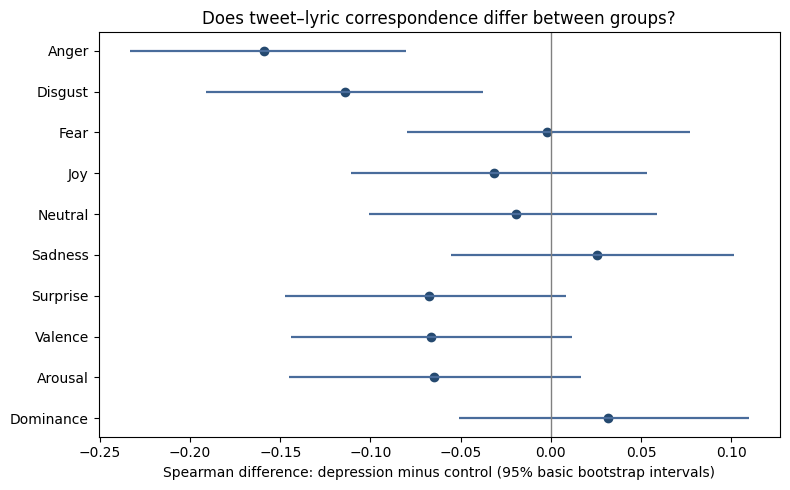

In [ ]:
def row_correlations(x, y):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    x = x - x.mean(axis=-1, keepdims=True); y = y - y.mean(axis=-1, keepdims=True)
    denominator = np.sqrt(np.sum(x*x, axis=-1) * np.sum(y*y, axis=-1))
    return np.divide(np.sum(x*y, axis=-1), denominator,
                     out=np.full(denominator.shape, np.nan), where=denominator>0)

def bootstrap_rho(x, y, rng, repeats, batch_size=48):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    result = np.empty(repeats)
    for start in range(0, repeats, batch_size):
        end = min(start+batch_size, repeats)
        idx = rng.integers(0, len(x), size=(end-start, len(x)))
        result[start:end] = row_correlations(rankdata(x[idx], axis=1), rankdata(y[idx], axis=1))
    return result

def group_difference(data, xcol, ycol, seed):
    dep = data[data.disorder.eq('depression')]; control = data[data.disorder.eq('control')]
    rd = float(spearmanr(dep[xcol], dep[ycol]).statistic)
    rc = float(spearmanr(control[xcol], control[ycol]).statistic)
    assert np.isfinite(rd) and np.isfinite(rc)
    observed = rd-rc; rng = np.random.default_rng(seed)
    boot = bootstrap_rho(dep[xcol], dep[ycol], rng, BOOTSTRAPS) - bootstrap_rho(control[xcol], control[ycol], rng, BOOTSTRAPS)
    boot = boot[np.isfinite(boot)]
    assert len(boot) >= .99*BOOTSTRAPS
    centred = boot-observed
    lo, hi = observed-np.quantile(centred, [.975,.025])
    lower = (1+np.count_nonzero(centred<=observed))/(len(centred)+1)
    upper = (1+np.count_nonzero(centred>=observed))/(len(centred)+1)
    p = min(1., 2*min(lower,upper))
    return {'depression_n':len(dep), 'control_n':len(control), 'depression_rho':rd,
            'control_rho':rc, 'difference':observed, 'ci_low':float(lo), 'ci_high':float(hi),
            'p_approx':float(p), 'valid_bootstraps':len(boot)}

difference_rows = []

for i,(name,x,y) in enumerate(tqdm(PAIRS, desc='Group correlation differences')):
    difference_rows.append(dict(measure=name, x=x, y=y, **group_difference(features,x,y,20261020+i)))

group_differences = pd.DataFrame(difference_rows)
group_differences['q_BH_10'] = multipletests(group_differences.p_approx, method='fdr_bh')[1]
group_differences.to_csv(RESULTS/'analysis/group_correlation_differences.csv', index=False)

display(group_differences[['measure','depression_rho','control_rho','difference','ci_low','ci_high','q_BH_10']])

fig,ax = plt.subplots(figsize=(8,5))
positions = np.arange(len(group_differences))
ax.hlines(positions, group_differences.ci_low, group_differences.ci_high, color='#496c9b', lw=1.6)
ax.scatter(group_differences.difference, positions, color='#24496f')
ax.axvline(0, color='grey', lw=1)
ax.set_yticks(positions, [s.title() for s in group_differences.measure]); ax.invert_yaxis()
ax.set_xlabel('Spearman difference: depression minus control (95% basic bootstrap intervals)')
ax.set_title('Does tweet–lyric correspondence differ between groups?')
fig.tight_layout(); save_figure(fig,'group_correlation_differences')

CHECK_STATUS['group_correlation_differences'] = True


## 6. See the relationships separately for each group
These plots show participant-mean predicted sadness and valence. Both groups use identical axis limits in each comparison. Each dot is one person, not an individual tweet/song pair. Lines are not fitted to imply a causal or time-ordered relationship.


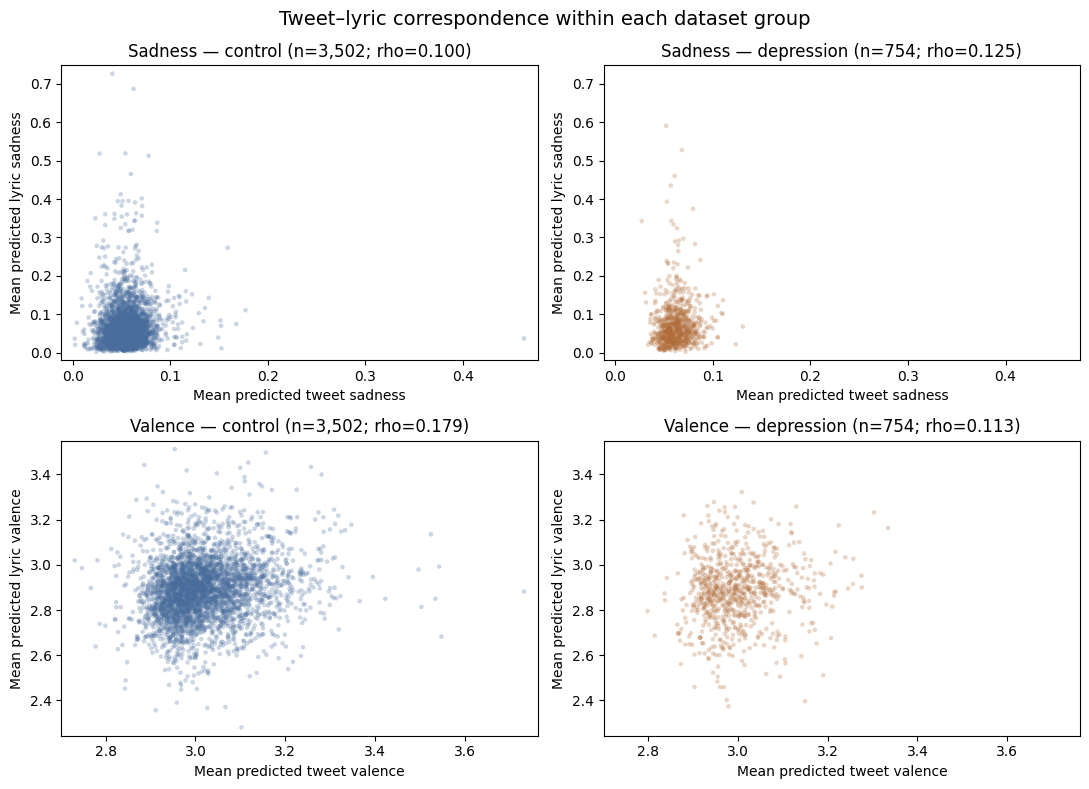

In [ ]:
fig,axes = plt.subplots(2,2,figsize=(11,8))

for row,(name,x,y) in enumerate([('Sadness','tweet_emotion_sadness','lyric_emotion_sadness'),('Valence','tweet_V','lyric_V')]):
    xmin,xmax = features[x].min(),features[x].max(); ymin,ymax = features[y].min(),features[y].max()
    xpad = max((xmax-xmin)*.03,.0001); ypad = max((ymax-ymin)*.03,.0001)
    for col,group in enumerate(['control','depression']):
        data = features[features.disorder.eq(group)]; ax = axes[row,col]
        ax.scatter(data[x],data[y],s=11,alpha=.28,color='#486c9c' if group=='control' else '#b06c39',edgecolors='none')
        rho = spearmanr(data[x],data[y]).statistic
        ax.set_xlim(xmin-xpad,xmax+xpad); ax.set_ylim(ymin-ypad,ymax+ypad)
        ax.set_title(f'{name} — {group} (n={len(data):,}; rho={rho:.3f})')
        ax.set_xlabel('Mean predicted tweet '+name.lower()); ax.set_ylabel('Mean predicted lyric '+name.lower())

fig.suptitle('Tweet–lyric correspondence within each dataset group', fontsize=14)
fig.tight_layout(); save_figure(fig,'sadness_valence_by_group')


## 7. Remove known music-sharing posts from the tweet averages
The same fitted emotion model scores only the supplied subset. Its participant sums are subtracted from the original tweet sums. Lyric scores, participant labels and folds are retained. Participants with no eligible tweets after removal are excluded and reported.

The VAD calculation is independently checked against the earlier completed music-post exclusion analysis. This does not identify every music-related tweet, which would require text; it removes the exact known sharing-post IDs.


In [ ]:
music = np.load(INPUT/'support/known_music_post_embeddings.npz', allow_pickle=False)
vectors = music['embeddings']; owners = music['participant_position']; global_rows = music['global_row']
assert music['participant_ids'].tolist() == features.participant_id.tolist()
assert vectors.shape == (subset_audit['eligible_known_music_posts_paired_sample'],384)
assert owners.shape == global_rows.shape == (len(vectors),)
assert np.all(np.diff(global_rows)>0) and owners.min()>=0 and owners.max()<len(features)
assert np.isfinite(vectors).all()

norm = np.linalg.norm(vectors,axis=1,keepdims=True); assert (norm>0).all()
normalized = vectors/norm
probability = softmax(normalized@COEF.T+INTERCEPT,axis=1)
assert probability.shape == (len(vectors),7) and np.allclose(probability.sum(axis=1),1,atol=1e-10)

vad_model = np.load(INPUT/'support/vad_ridge.npz', allow_pickle=False)
vad_probability = normalized@vad_model['coef'].T+vad_model['intercept']
removed_n = np.bincount(owners,minlength=len(features))
removed_category_sum = np.zeros((len(features),7)); removed_vad_sum = np.zeros((len(features),3))
np.add.at(removed_category_sum,owners,probability); np.add.at(removed_vad_sum,owners,vad_probability)
original_n = features.tweet_count.to_numpy(dtype=np.int64)
remaining_n = original_n-removed_n
assert (remaining_n>=0).all()

keep = remaining_n>0
nonmusic = features.loc[keep].copy().reset_index(drop=True)
nonmusic[TCOLS] = (features[TCOLS].to_numpy()[keep]*original_n[keep,None]-removed_category_sum[keep])/remaining_n[keep,None]
nonmusic[['tweet_V','tweet_A','tweet_D']] = (features[['tweet_V','tweet_A','tweet_D']].to_numpy()[keep]*original_n[keep,None]-removed_vad_sum[keep])/remaining_n[keep,None]
nonmusic['tweet_count'] = remaining_n[keep]
nonmusic['log_tweet_count'] = np.log1p(nonmusic.tweet_count)
assert np.isfinite(nonmusic[TCOLS+VADCOLS].to_numpy()).all()
assert nonmusic[TCOLS].to_numpy().min()>=-1e-10 and nonmusic[TCOLS].to_numpy().max()<=1+1e-10
assert np.allclose(nonmusic[TCOLS].sum(axis=1),1,atol=1e-9)
assert np.array_equal(nonmusic[LCOLS+['lyric_V','lyric_A','lyric_D']].to_numpy(), features.loc[keep,LCOLS+['lyric_V','lyric_A','lyric_D']].to_numpy())

previous_vad = pd.read_csv(INPUT/'support/tweet_vad_music_posts_excluded.csv',dtype={'participant_id':str}).set_index('participant_id').loc[nonmusic.participant_id]
assert np.array_equal(nonmusic.tweet_count,previous_vad.tweet_count)

max_vad_error = float(np.max(np.abs(nonmusic[['tweet_V','tweet_A','tweet_D']].to_numpy()-previous_vad[['tweet_V','tweet_A','tweet_D']].to_numpy())))
assert max_vad_error<1e-6, 'Music exclusion differs from the independent VAD calculation.'
assert len(nonmusic)==subset_audit['paired_participants_after_exclusion']

audit = {'original_participants':len(features), 'remaining_participants':len(nonmusic),
         'removed_known_posts':int(removed_n.sum()), 'original_tweets':int(original_n.sum()),
         'remaining_tweets':int(nonmusic.tweet_count.sum()), 'participants_affected':int((removed_n>0).sum()),
         'participants_with_no_remaining_posts':features.loc[~keep,'participant_id'].tolist(),
         'remaining_groups':nonmusic.disorder.value_counts().to_dict(), 'VAD_reproduction_max_error':max_vad_error,
         'lyrics_unchanged':True, 'original_fold_ids_retained':True}

write_json(RESULTS/'analysis/music_exclusion_audit.json',audit)
nonmusic.to_csv(RESULTS/'analysis/participant_features_music_posts_excluded.csv',index=False)

print(json.dumps(audit,indent=2))


{
  "original_participants": 4256,
  "remaining_participants": 4255,
  "removed_known_posts": 23383,
  "original_tweets": 6345978,
  "remaining_tweets": 6322595,
  "participants_affected": 3187,
  "participants_with_no_remaining_posts": [
    "efb25c210325e91ae7f53cab"
  ],
  "remaining_groups": {
    "control": 3501,
    "depression": 754
  },
  "VAD_reproduction_max_error": 2.384185791015625e-07,
  "lyrics_unchanged": true,
  "original_fold_ids_retained": true
}


## 8. Do correspondence and group differences persist after exclusion?
The original and excluded-post summaries below use the **same remaining participants**. Changes in mean scores, matching correlations and Cliff's delta are descriptive robustness checks. We do not turn every sensitivity result into another significance test.


variant,music_posts_excluded,original_same_participants
measure,,
anger,0.306685,0.307211
arousal,-0.030727,-0.031441
disgust,0.212625,0.212661
dominance,0.088259,0.090663
fear,0.115277,0.117731
joy,0.045671,0.045544
neutral,0.027660,0.027687
sadness,0.111436,0.114474
surprise,0.038546,0.040474


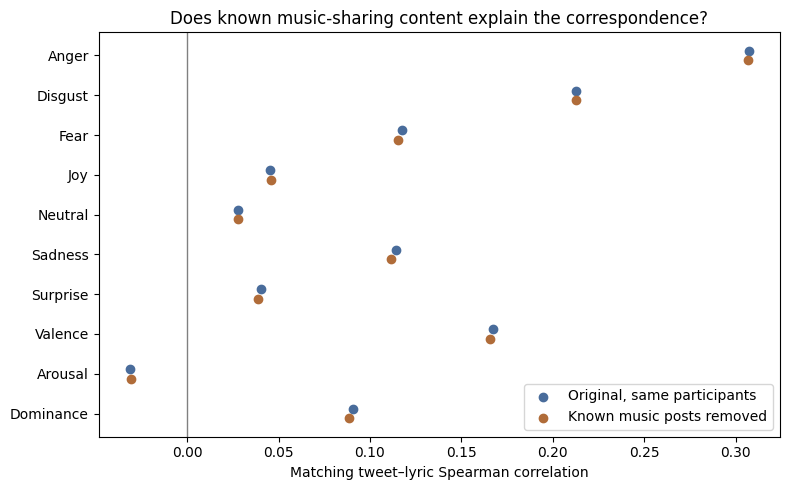

In [ ]:
original_common = features.set_index('participant_id').loc[nonmusic.participant_id].reset_index()
correlation_rows = []; effect_rows = []

for variant,data in [('original_same_participants',original_common),('music_posts_excluded',nonmusic)]:
    for group in ['all','control','depression']:
        sub = data if group=='all' else data[data.disorder.eq(group)]
        for name,x,y in PAIRS:
            correlation_rows.append({'variant':variant,'group':group,'measure':name,'n':len(sub),
                                     'rho':float(spearmanr(sub[x],sub[y]).statistic)})
    for source,cols in [('tweet',TCOLS),('lyric',LCOLS)]:
        for label,col in zip(LABELS,cols):
            dep = data.loc[data.disorder.eq('depression'),col].to_numpy()
            control = data.loc[data.disorder.eq('control'),col].to_numpy()
            u = mannwhitneyu(dep,control,alternative='two-sided',method='asymptotic').statistic
            effect_rows.append({'variant':variant,'source':source,'category':label,
                               'depression_mean':float(dep.mean()),'control_mean':float(control.mean()),
                               'cliffs_delta':float(2*u/(len(dep)*len(control))-1)})

exclusion_correlations = pd.DataFrame(correlation_rows)
exclusion_effects = pd.DataFrame(effect_rows)
exclusion_correlations.to_csv(RESULTS/'analysis/music_exclusion_correlations.csv',index=False)
exclusion_effects.to_csv(RESULTS/'analysis/music_exclusion_group_effects.csv',index=False)

display(exclusion_correlations.query('group=="all"').pivot(index='measure',columns='variant',values='rho'))

fig,ax = plt.subplots(figsize=(8,5))
matrix = exclusion_correlations.query('group=="all"').pivot(index='measure',columns='variant',values='rho').reindex([p[0] for p in PAIRS])
pos = np.arange(len(matrix))
ax.scatter(matrix.original_same_participants,pos-.12,label='Original, same participants',color='#496c9b')
ax.scatter(matrix.music_posts_excluded,pos+.12,label='Known music posts removed',color='#b06c39')
ax.set_yticks(pos,[s.title() for s in matrix.index]); ax.invert_yaxis(); ax.axvline(0,color='grey',lw=1)
ax.set_xlabel('Matching tweet–lyric Spearman correlation'); ax.legend(loc='best')
ax.set_title('Does known music-sharing content explain the correspondence?')
fig.tight_layout(); save_figure(fig,'music_exclusion_correlations')


## 9. Account for the number of tweets and songs
Partial rank correlations compare ranked tweet and lyric scores after removing their linear association with ranked tweet count and ranked song count. The pooled analysis also accounts for dataset group; within each group only the two activity counts are included. These are descriptive adjusted associations, not proof that all confounding has been removed.

We additionally report the original relationships in two separately specified cohorts: **at least 100 tweets** and **at least 3 songs**. These restrictions change the participant population, so their scores should not be treated as paired improvements over the full sample.


,variant,n,control,depression
0,primary,4256,3502,754
1,at_least_100_tweets,3851,3123,728
2,at_least_3_songs,2282,1893,389


,measure,raw_rho,partial_rank_r
0,anger,0.307433,0.290334
1,disgust,0.212383,0.187145
2,fear,0.117799,0.069198
3,joy,0.045421,0.051271
4,neutral,0.028259,0.029365
5,sadness,0.115042,0.098456
6,surprise,0.040679,0.048113
7,valence,0.166862,0.163018
8,arousal,-0.031149,-0.030834
9,dominance,0.091212,0.083652


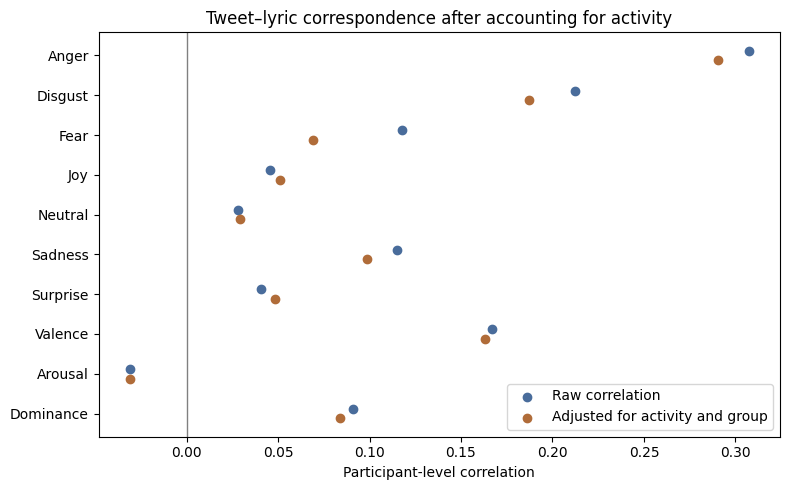

In [ ]:
def partial_rank_correlation(data,xcol,ycol,include_group):
    x = rankdata(data[xcol].to_numpy()); y = rankdata(data[ycol].to_numpy())
    covariates = [np.ones(len(data)),rankdata(data.tweet_count),rankdata(data.song_count)]
    if include_group:
        covariates.append(data.disorder.eq('depression').astype(float).to_numpy())
    z = np.column_stack(covariates)
    xr = x-z@np.linalg.lstsq(z,x,rcond=None)[0]
    yr = y-z@np.linalg.lstsq(z,y,rcond=None)[0]
    result = float(row_correlations(xr,yr))
    assert np.isfinite(result)
    return result

activity_cohorts = {'primary':features,
                    'at_least_100_tweets':features[features.tweet_count>=MIN_TWEETS].copy(),
                    'at_least_3_songs':features[features.song_count>=MIN_SONGS].copy()}
activity_rows = []; activity_audit = []
for variant,data in activity_cohorts.items():
    activity_audit.append({'variant':variant,'n':len(data),**data.disorder.value_counts().to_dict()})
    for group in ['all','control','depression']:
        sub = data if group=='all' else data[data.disorder.eq(group)]
        assert len(sub)>20
        for name,x,y in PAIRS:
            activity_rows.append({'variant':variant,'group':group,'measure':name,'n':len(sub),
                                  'raw_rho':float(spearmanr(sub[x],sub[y]).statistic),
                                  'partial_rank_r':partial_rank_correlation(sub,x,y,include_group=(group=='all'))})

activity_correlations = pd.DataFrame(activity_rows)
activity_correlations.to_csv(RESULTS/'analysis/activity_adjusted_correlations.csv',index=False)
pd.DataFrame(activity_audit).to_csv(RESULTS/'analysis/activity_cohort_sizes.csv',index=False)
display(pd.DataFrame(activity_audit))
display(activity_correlations.query('variant=="primary" and group=="all"')[['measure','raw_rho','partial_rank_r']])

fig,ax = plt.subplots(figsize=(8,5))
sub = activity_correlations.query('variant=="primary" and group=="all"').set_index('measure').loc[[p[0] for p in PAIRS]]
pos = np.arange(len(sub))
ax.scatter(sub.raw_rho,pos-.12,color='#496c9b',label='Raw correlation')
ax.scatter(sub.partial_rank_r,pos+.12,color='#b06c39',label='Adjusted for activity and group')
ax.set_yticks(pos,[s.title() for s in sub.index]); ax.invert_yaxis(); ax.axvline(0,color='grey',lw=1)
ax.set_xlabel('Participant-level correlation'); ax.legend(loc='best')
ax.set_title('Tweet–lyric correspondence after accounting for activity')
fig.tight_layout(); save_figure(fig,'activity_adjusted_correlations')


## 10. Refit the classifiers on the original folds
We keep the original models/settings and five fold IDs. Imputation and scaling are fitted only on each training fold. No participant appears in their own training data.

For the music-exclusion comparison, both original and excluded-post models use exactly the same remaining participants. The lyric-only feature matrix is unchanged. The activity restrictions use the same original fold IDs on their new cohorts. Three further feature sets assess activity alone, tweets plus activity, and tweets/lyrics plus activity.

Historical primary predictions are reused without modification. All new predictions are labelled separately. Caches include the actual feature matrices, labels, participant identities, folds, settings and package versions, so an interrupted run can resume each model fold safely.


In [ ]:
BASE_SETS = {'VAD_both':VADCOLS, 'category_tweets':TCOLS, 'category_lyrics':LCOLS,
             'category_both':TCOLS+LCOLS, 'VAD_and_categories':VADCOLS+TCOLS+LCOLS}
ACTIVITY_COLS = ['log_tweet_count','log_song_count']
ACTIVITY_SETS = {'activity_only':ACTIVITY_COLS,
                 'category_tweets_and_activity':TCOLS+ACTIVITY_COLS,
                 'category_both_and_activity':TCOLS+LCOLS+ACTIVITY_COLS}
prototypes = {'LR':make_pipeline(SimpleImputer(strategy='median'),StandardScaler(),
               LogisticRegression(C=1,class_weight='balanced',max_iter=5000,random_state=SEED))}
if INCLUDE_RANDOM_FOREST:
    prototypes['RF'] = make_pipeline(SimpleImputer(strategy='median'),
        RandomForestClassifier(n_estimators=300,min_samples_leaf=3,class_weight='balanced_subsample',random_state=SEED,n_jobs=2))
model_settings = {'LR':{'C':1,'class_weight':'balanced','max_iter':5000,'random_state':SEED},
                  'RF':{'n_estimators':300,'min_samples_leaf':3,'class_weight':'balanced_subsample','random_state':SEED,'n_jobs':2}}

def cv_predictions(data,cols,model):
    X = data[cols].to_numpy(dtype=np.float64)
    yy = data.disorder.eq('depression').to_numpy(dtype=np.int64)
    ff = data.fold.to_numpy(dtype=np.int64)
    assert np.isfinite(X).all() and set(ff)==set(range(1,6))

    metadata = {'code_version':CODE_VERSION,'model':model,'settings':model_settings[model],
                'columns':cols,'participants':data.participant_id.tolist(),'packages':PACKAGE_VERSIONS}
    h = hashlib.sha256(json.dumps(metadata,sort_keys=True).encode())

    for array in [X,yy,ff]: h.update(np.ascontiguousarray(array).tobytes())

    key = h.hexdigest(); path = CACHE/('cv_'+key+'.npz')
    probability = np.full(len(data),np.nan); predicted = np.full(len(data),-1,dtype=np.int64)
    completed = np.zeros(5,dtype=bool)

    if path.exists():
        saved = np.load(path,allow_pickle=False)
        probability,predicted,completed = saved['probability'].copy(),saved['predicted'].copy(),saved['completed'].copy()
        assert probability.shape==predicted.shape==(len(data),) and completed.shape==(5,)

    for fold in range(1,6):
        if completed[fold-1]: continue
        validation = ff==fold; training = ~validation
        assert set(yy[training])==set(yy[validation])=={0,1}
        with warnings.catch_warnings():
            warnings.simplefilter('error',ConvergenceWarning)
            fitted = clone(prototypes[model]).fit(X[training],yy[training])
        probability[validation] = fitted.predict_proba(X[validation])[:,1]
        predicted[validation] = fitted.predict(X[validation])
        completed[fold-1] = True
        save_npz(path,probability=probability,predicted=predicted,completed=completed)
    assert completed.all() and np.isfinite(probability).all()
    assert ((probability>=0)&(probability<=1)).all() and set(predicted).issubset({0,1})
    return pd.DataFrame({'participant_id':data.participant_id.to_numpy(),'fold':ff,'y':yy,
                         'probability':probability,'predicted':predicted,'prediction_cache_key':key})

def historical_predictions(data,name,model):
    sub = old_oof[(old_oof.features==name)&(old_oof.model==model)].set_index('participant_id').loc[data.participant_id].reset_index()
    assert np.array_equal(sub.fold,data.fold) and np.array_equal(sub.y,data.disorder.eq('depression').astype(int))
    result = sub[['participant_id','fold','y','probability','predicted']].copy()
    result['prediction_cache_key'] = 'historical_original_predictions'
    return result

prediction_parts = []
def record_predictions(variant,data,sets,use_historical=False):
    for name,cols in tqdm(list(sets.items()),desc=variant):
        for model in prototypes:
            result = historical_predictions(data,name,model) if use_historical else cv_predictions(data,cols,model)
            result['variant'] = variant; result['features'] = name; result['model'] = model; result['feature_count'] = len(cols)
            prediction_parts.append(result)
            pd.concat(prediction_parts,ignore_index=True).to_csv(RESULTS/'analysis/followup_classification_oof.csv',index=False)

record_predictions('primary',features,BASE_SETS,use_historical=True)
record_predictions('original_same_nonmusic_participants',original_common,BASE_SETS,use_historical=(len(original_common)==len(features)))
record_predictions('music_posts_excluded',nonmusic,BASE_SETS)

for variant,data in activity_cohorts.items():
    if variant!='primary': record_predictions(variant,data,BASE_SETS)

record_predictions('primary',features,ACTIVITY_SETS)
followup_oof = pd.concat(prediction_parts,ignore_index=True)
assert not followup_oof.duplicated(['variant','features','model','participant_id']).any()

print('New predictions complete; original predictions retained separately.')


primary:   0%|          | 0/5 [00:00<?, ?it/s]

original_same_nonmusic_participants:   0%|          | 0/5 [00:00<?, ?it/s]

music_posts_excluded:   0%|          | 0/5 [00:00<?, ?it/s]

at_least_100_tweets:   0%|          | 0/5 [00:00<?, ?it/s]

at_least_3_songs:   0%|          | 0/5 [00:00<?, ?it/s]

primary:   0%|          | 0/3 [00:00<?, ?it/s]

New predictions complete; original predictions retained separately.


## 11. Summarise prediction and the paired comparisons
Average fold AUROC and balanced accuracy preserve the earlier reporting convention. Pooled AUROC/average precision and confusion counts are calculated from one held-out prediction per participant. The AUROC bootstrap resamples within label groups.

The paired music-exclusion changes compare the same people and folds. Combined-minus-tweets comparisons assess the contribution of lyrics within each cohort; the activity-adjusted comparison includes the same count covariates on both sides. Pointwise intervals are exploratory and not adjusted for all these comparisons. An interval including zero leaves the improvement uncertain; it does not prove equality.


Prediction summaries:   0%|          | 0/56 [00:00<?, ?it/s]

,variant,features,n,mean_fold_auroc,mean_fold_balanced_accuracy
0,at_least_100_tweets,VAD_and_categories,3851,0.716218,0.650175
2,at_least_100_tweets,VAD_both,3851,0.642192,0.604623
4,at_least_100_tweets,category_both,3851,0.717347,0.651829
6,at_least_100_tweets,category_lyrics,3851,0.587621,0.567234
8,at_least_100_tweets,category_tweets,3851,0.714076,0.645035
10,at_least_3_songs,VAD_and_categories,2282,0.743417,0.678265
12,at_least_3_songs,VAD_both,2282,0.660125,0.608137
14,at_least_3_songs,category_both,2282,0.742329,0.669454
16,at_least_3_songs,category_lyrics,2282,0.615308,0.590088
18,at_least_3_songs,category_tweets,2282,0.730054,0.662337


,comparison,model,n,variant_a,features_a,variant_b,features_b,pooled_auroc_difference,ci_low,ci_high
0,music_exclusion_minus_original_VAD_both,LR,4255,music_posts_excluded,VAD_both,original_same_nonmusic_participants,VAD_both,0.000028,-0.000627,0.000728
1,music_exclusion_minus_original_category_tweets,LR,4255,music_posts_excluded,category_tweets,original_same_nonmusic_participants,category_tweets,-0.000519,-0.001470,0.000406
2,music_exclusion_minus_original_category_lyrics,LR,4255,music_posts_excluded,category_lyrics,original_same_nonmusic_participants,category_lyrics,0.000000,0.000000,0.000000
3,music_exclusion_minus_original_category_both,LR,4255,music_posts_excluded,category_both,original_same_nonmusic_participants,category_both,-0.000434,-0.001297,0.000443
4,music_exclusion_minus_original_VAD_and_categories,LR,4255,music_posts_excluded,VAD_and_categories,original_same_nonmusic_participants,VAD_and_categories,-0.000345,-0.001286,0.000657
5,lyrics_increment_primary,LR,4256,primary,category_both,primary,category_tweets,0.004997,-0.000623,0.010676
6,lyrics_increment_music_posts_excluded,LR,4255,music_posts_excluded,category_both,music_posts_excluded,category_tweets,0.005084,-0.000678,0.010625
7,lyrics_increment_at_least_100_tweets,LR,3851,at_least_100_tweets,category_both,at_least_100_tweets,category_tweets,0.003323,-0.001301,0.007974
8,lyrics_increment_at_least_3_songs,LR,2282,at_least_3_songs,category_both,at_least_3_songs,category_tweets,0.012116,0.001381,0.023386
9,emotion_information_beyond_activity,LR,4256,primary,category_both_and_activity,primary,activity_only,0.109933,0.090215,0.130964


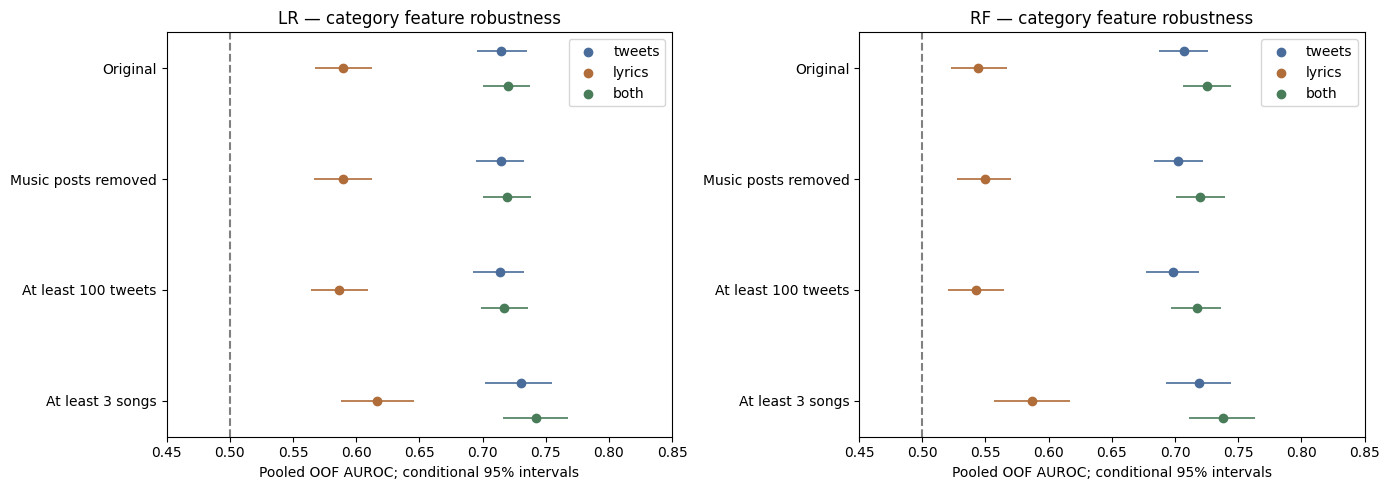

In [ ]:
def auc_bootstrap(y,p,rng,repeats,q=None,batch_size=48):
    yy = np.asarray(y); p = np.asarray(p,dtype=float)
    positive = np.flatnonzero(yy==1); negative = np.flatnonzero(yy==0)
    assert len(positive)>0 and len(negative)>0
    if q is not None: q = np.asarray(q,dtype=float); assert q.shape==p.shape
    values = np.empty(repeats); npos = len(positive); nneg = len(negative)
    def auc_for_sample(scores):
        ranks = rankdata(scores,axis=1)
        return (ranks[:,:npos].sum(axis=1)-npos*(npos+1)/2)/(npos*nneg)
    for start in range(0,repeats,batch_size):
        end = min(start+batch_size,repeats)
        idx = np.concatenate([rng.choice(positive,(end-start,npos),replace=True),
                              rng.choice(negative,(end-start,nneg),replace=True)],axis=1)
        values[start:end] = auc_for_sample(p[idx])
        if q is not None: values[start:end] -= auc_for_sample(q[idx])
    return values

def prediction_metrics(data):
    yy = data.y.to_numpy(); p = data.probability.to_numpy(); predicted = data.predicted.to_numpy()
    tn,fp,fn,tp = confusion_matrix(yy,predicted,labels=[0,1]).ravel()
    sensitivity = tp/(tp+fn); specificity = tn/(tn+fp)
    return {'n':len(data),'depression_n':int(yy.sum()),'prevalence':float(yy.mean()),
            'pooled_auroc':float(roc_auc_score(yy,p)),'average_precision':float(average_precision_score(yy,p)),
            'balanced_accuracy':float((sensitivity+specificity)/2),'accuracy':float((tp+tn)/len(data)),
            'sensitivity':float(sensitivity),'specificity':float(specificity),
            'precision':float(tp/(tp+fp)) if tp+fp else 0.,
            'negative_predictive_value':float(tn/(tn+fn)) if tn+fn else 0.,
            'true_negative':int(tn),'false_positive':int(fp),'false_negative':int(fn),'true_positive':int(tp)}

summary_rows = []; fold_rows = []
for i,((variant,name,model),data) in enumerate(tqdm(list(followup_oof.groupby(['variant','features','model'])),desc='Prediction summaries')):
    metrics = prediction_metrics(data)
    ff = []
    for fold,part in data.groupby('fold'):
        row = dict(variant=variant,features=name,model=model,fold=int(fold),**prediction_metrics(part))
        ff.append(row); fold_rows.append(row)
    interval = np.quantile(auc_bootstrap(data.y,data.probability,np.random.default_rng(20261100+i),BOOTSTRAPS),[.025,.975])
    summary_rows.append(dict(variant=variant,features=name,model=model,feature_count=int(data.feature_count.iloc[0]),
        mean_fold_auroc=float(np.mean([r['pooled_auroc'] for r in ff])),
        sd_fold_auroc=float(np.std([r['pooled_auroc'] for r in ff],ddof=1)),
        mean_fold_balanced_accuracy=float(np.mean([r['balanced_accuracy'] for r in ff])),
        ci_low=float(interval[0]),ci_high=float(interval[1]),**metrics))
classification_summary = pd.DataFrame(summary_rows)
classification_summary.to_csv(RESULTS/'analysis/followup_classification_summary.csv',index=False)
pd.DataFrame(fold_rows).to_csv(RESULTS/'analysis/followup_classification_folds.csv',index=False)

def get_predictions(variant,name,model):
    result = followup_oof[(followup_oof.variant==variant)&(followup_oof.features==name)&(followup_oof.model==model)]
    assert len(result)>0
    return result.sort_values('participant_id').reset_index(drop=True)

paired_rows = []
def paired_comparison(label,variant_a,name_a,variant_b,name_b,model):
    a = get_predictions(variant_a,name_a,model); b = get_predictions(variant_b,name_b,model)
    assert a.participant_id.tolist()==b.participant_id.tolist()
    assert np.array_equal(a.y,b.y) and np.array_equal(a.fold,b.fold)
    estimate = roc_auc_score(a.y,a.probability)-roc_auc_score(b.y,b.probability)
    values = auc_bootstrap(a.y,a.probability,np.random.default_rng(20261200+len(paired_rows)),BOOTSTRAPS,q=b.probability)
    lo,hi = np.quantile(values,[.025,.975])
    paired_rows.append({'comparison':label,'model':model,'n':len(a),'variant_a':variant_a,'features_a':name_a,
        'variant_b':variant_b,'features_b':name_b,'pooled_auroc_difference':float(estimate),
        'ci_low':float(lo),'ci_high':float(hi)})

for model in prototypes:
    for name in BASE_SETS:
        paired_comparison('music_exclusion_minus_original_'+name,'music_posts_excluded',name,
                          'original_same_nonmusic_participants',name,model)
    for variant in ['primary','music_posts_excluded','at_least_100_tweets','at_least_3_songs']:
        paired_comparison('lyrics_increment_'+variant,variant,'category_both',variant,'category_tweets',model)
    paired_comparison('emotion_information_beyond_activity','primary','category_both_and_activity','primary','activity_only',model)
    paired_comparison('activity_increment_to_categories','primary','category_both_and_activity','primary','category_both',model)
    paired_comparison('lyrics_increment_with_activity_controls','primary','category_both_and_activity','primary','category_tweets_and_activity',model)

paired = pd.DataFrame(paired_rows)
paired.to_csv(RESULTS/'analysis/followup_paired_comparisons.csv',index=False)
display(classification_summary.query('model=="LR"')[['variant','features','n','mean_fold_auroc','mean_fold_balanced_accuracy']])
display(paired.query('model=="LR"'))

fig,axes = plt.subplots(1,len(prototypes),figsize=(7*len(prototypes),5),squeeze=False)
names = ['primary','music_posts_excluded','at_least_100_tweets','at_least_3_songs']

for ax,model in zip(axes[0],prototypes):
    for j,name in enumerate(['category_tweets','category_lyrics','category_both']):
        sub = classification_summary[(classification_summary.model==model)&(classification_summary.features==name)].set_index('variant').loc[names]
        pos = np.arange(4)+(j-1)*.16
        ax.hlines(pos,sub.ci_low,sub.ci_high,color=['#496c9b','#b06c39','#497d5a'][j],lw=1.2)
        ax.scatter(sub.pooled_auroc,pos,label=name.replace('category_','').replace('_',' '),color=['#496c9b','#b06c39','#497d5a'][j])
    ax.axvline(.5,color='grey',ls='--'); ax.set_xlim(.45,.85)
    ax.set_yticks(range(4),['Original','Music posts removed','At least 100 tweets','At least 3 songs'])
    ax.invert_yaxis(); ax.set_title(model+' — category feature robustness')
    ax.set_xlabel('Pooled OOF AUROC; conditional 95% intervals'); ax.legend(loc='best')

fig.tight_layout(); save_figure(fig,'classification_robustness')

CHECK_STATUS['music_post_exclusion'] = True
CHECK_STATUS['activity_checks'] = True


## 12. Understand the actual classification errors
These tables and figures use the **original** saved held-out predictions. Depression is the positive class. Sensitivity is the fraction of depression-labelled participants detected; specificity is the fraction of controls correctly identified; precision is the fraction of flagged participants who carry the depression label.

Because the groups are imbalanced, overall accuracy can be misleading: predicting control for everyone would produce about 82% accuracy and 50% balanced accuracy here. Average precision is compared with the dataset prevalence, not with 0.5. The default thresholds are retained and the class-weighted scores are not presented as calibrated clinical probabilities.

The confusion plots show counts and percentages within each actual group. Precision/recall curves display discrimination across thresholds for explanation; no threshold is selected from these curves.


,features,model,sensitivity,specificity,precision,balanced_accuracy,false_negative,false_positive
0,VAD_and_categories,LR,0.665782,0.658766,0.295816,0.662274,252,1195
1,VAD_and_categories,RF,0.143236,0.969446,0.502326,0.556341,646,107
2,VAD_both,LR,0.587533,0.613649,0.246659,0.600591,311,1353
3,VAD_both,RF,0.063660,0.966876,0.292683,0.515268,706,116
4,category_both,LR,0.652520,0.663906,0.294787,0.658213,262,1177
5,category_both,RF,0.145889,0.963735,0.464135,0.554812,644,127
6,category_lyrics,LR,0.529178,0.613935,0.227870,0.571556,355,1352
7,category_lyrics,RF,0.029178,0.980868,0.247191,0.505023,732,67
8,category_tweets,LR,0.644562,0.656482,0.287744,0.650522,268,1203
9,category_tweets,RF,0.169761,0.944889,0.398754,0.557325,626,193


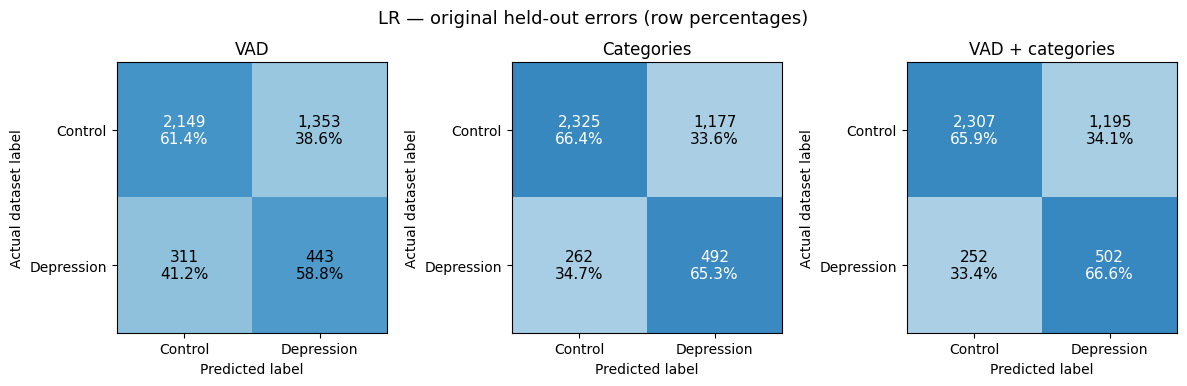

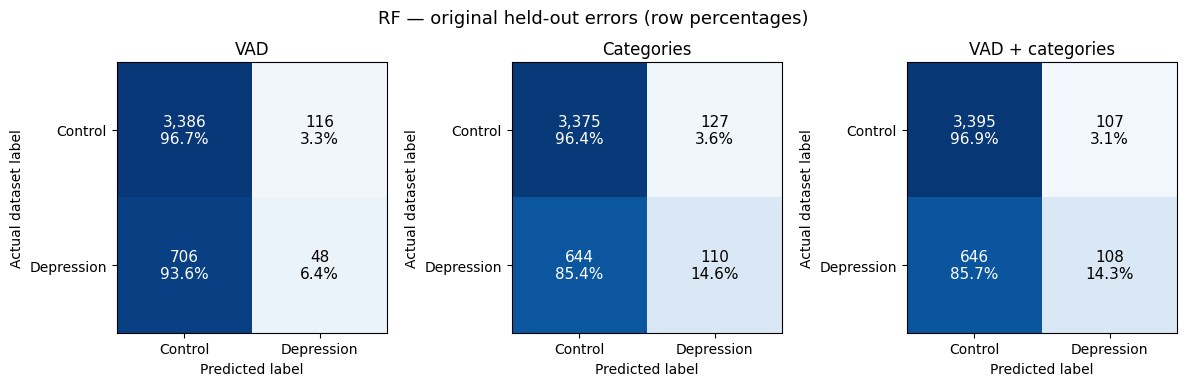

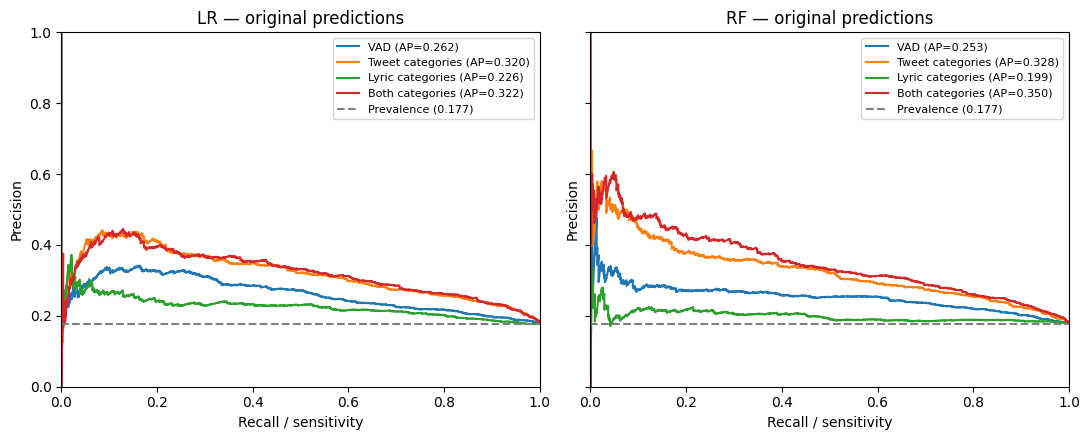

In [ ]:
error_rows = []

for (name,model),data in old_oof.groupby(['features','model']):
    error_rows.append(dict(features=name,model=model,**prediction_metrics(data)))
error_metrics = pd.DataFrame(error_rows)
error_metrics.to_csv(RESULTS/'analysis/original_classification_errors.csv',index=False)
prevalence = float(y_original.mean())

write_json(RESULTS/'analysis/classification_error_definitions.json',{
    'positive_label':'depression', 'threshold':.5, 'prevalence':prevalence,
    'always_control_accuracy':float(1-prevalence), 'always_control_balanced_accuracy':.5,
    'average_precision_no_skill_baseline':prevalence,
    'confusion_orientation':'Rows: actual control/depression. Columns: predicted control/depression.',
    'scope':'Dataset-label errors on saved OOF predictions, without threshold tuning or clinical calibration.'})

display(error_metrics[['features','model','sensitivity','specificity','precision','balanced_accuracy','false_negative','false_positive']])

for model in ['LR','RF']:
    fig,axes = plt.subplots(1,3,figsize=(12,3.8))
    for ax,name,title in zip(axes,['VAD_both','category_both','VAD_and_categories'],['VAD','Categories','VAD + categories']):
        part = old_oof[(old_oof.features==name)&(old_oof.model==model)]
        counts = confusion_matrix(part.y,part.predicted,labels=[0,1])
        fractions = counts/counts.sum(axis=1,keepdims=True)
        ax.imshow(fractions,vmin=0,vmax=1,cmap='Blues')
        for i in range(2):
            for j in range(2):
                ax.text(j,i,f'{counts[i,j]:,}\n{fractions[i,j]:.1%}',ha='center',va='center',
                        color='white' if fractions[i,j]>.6 else 'black',fontsize=11)
        ax.set_xticks([0,1],['Control','Depression']); ax.set_yticks([0,1],['Control','Depression'])
        ax.set_xlabel('Predicted label'); ax.set_ylabel('Actual dataset label'); ax.set_title(title)
    fig.suptitle(model+' — original held-out errors (row percentages)',fontsize=13)
    fig.tight_layout(); save_figure(fig,'confusion_matrices_'+model)

fig,axes = plt.subplots(1,2,figsize=(11,4.5),sharey=True)

for ax,model in zip(axes,['LR','RF']):
    for name,title in [('VAD_both','VAD'),('category_tweets','Tweet categories'),('category_lyrics','Lyric categories'),('category_both','Both categories')]:
        part = old_oof[(old_oof.features==name)&(old_oof.model==model)]
        precision,recall,_ = precision_recall_curve(part.y,part.probability)
        ap = average_precision_score(part.y,part.probability)
        ax.plot(recall,precision,label=f'{title} (AP={ap:.3f})')
    ax.axhline(prevalence,color='grey',ls='--',label=f'Prevalence ({prevalence:.3f})')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_xlabel('Recall / sensitivity'); ax.set_ylabel('Precision')
    ax.set_title(model+' — original predictions'); ax.legend(fontsize=8)

fig.tight_layout(); save_figure(fig,'precision_recall_original')
CHECK_STATUS['classification_errors'] = True


## 13. Save the completed summary and results ZIP
This cell writes the completion markers only after all four checks finish. A `results` folder created earlier is not itself proof of completion. The report names the files supporting each finding and keeps uncertainty explicit. Download the ZIP, then share it for interpretation and incorporation into the thesis.


In [ ]:
required = ['group_correlation_differences','music_post_exclusion','activity_checks','classification_errors']
assert all(CHECK_STATUS.get(name,False) for name in required), 'One or more checks did not finish.'

sad = group_differences.set_index('measure').loc['sadness']
adjusted_sad = activity_correlations.query('variant=="primary" and group=="all" and measure=="sadness"').iloc[0]
cat_errors = error_metrics[(error_metrics.features=='category_both')&(error_metrics.model=='LR')].iloc[0]

lines = ['# Thesis final checks', '',
    'Completed all four configured checks. These are exploratory follow-ups to the primary results.', '',
    '## 1. Sadness correspondence between groups',
    f'Depression rho: {sad.depression_rho:.3f}; control rho: {sad.control_rho:.3f}.',
    f'Difference: {sad.difference:+.3f}; basic 95% CI [{sad.ci_low:.3f}, {sad.ci_high:.3f}]; approximate BH q across 10 differences: {sad.q_BH_10:.4f}.',
    'A small positive difference is not automatically convincing evidence of a group difference. An interval containing zero leaves it uncertain; it does not establish equality.', '',
    '## 2. Known music-sharing posts removed',
    f'Removed {audit["removed_known_posts"]:,} eligible known posts. Remaining: {len(nonmusic):,} participants and {audit["remaining_tweets"]:,} tweets.',
    f'Independent VAD reproduction error: {max_vad_error:.2e}. Lyrics and saved fold IDs were retained.',
    'Matching correlations and group effects use the same remaining people before and after removal.', '']

for model in prototypes:
    row = paired[(paired.model==model)&(paired.comparison=='music_exclusion_minus_original_category_both')].iloc[0]
    lines.append(f'{model}: category-both exclusion-minus-original pooled AUROC change {row.pooled_auroc_difference:+.4f}, conditional 95% CI [{row.ci_low:.4f}, {row.ci_high:.4f}].')

lines += ['', '## 3. Activity checks',
    f'Pooled sadness correspondence: raw rho {adjusted_sad.raw_rho:.3f}; activity/group-adjusted partial rank correlation {adjusted_sad.partial_rank_r:.3f}.',
    'Adjusted correlations are descriptive, and adjusting these measured counts does not remove every source of confounding.',
    'Separate minimum-activity cohorts change the population; their performance differences from the full sample are not paired treatment effects.', '']

for model in prototypes:
    for comparison in ['emotion_information_beyond_activity','lyrics_increment_with_activity_controls']:
        row = paired[(paired.model==model)&(paired.comparison==comparison)].iloc[0]
        lines.append(f'{model}, {comparison.replace("_"," ")}: pooled AUROC difference {row.pooled_auroc_difference:+.4f}, conditional 95% CI [{row.ci_low:.4f}, {row.ci_high:.4f}].')

lines += ['', '## 4. Original classification errors',
    f'LR with both category sources: sensitivity {cat_errors.sensitivity:.1%}, specificity {cat_errors.specificity:.1%}, precision {cat_errors.precision:.1%}, balanced accuracy {cat_errors.balanced_accuracy:.1%}.',
    f'Missed depression-labelled participants: {int(cat_errors.false_negative):,}; incorrectly flagged controls: {int(cat_errors.false_positive):,}.',
    'These are disclosure-derived dataset-label errors, not clinically validated diagnostic errors.', '',
    '## Interpretation limits',
    'The emotion models are fixed; human-rated emotion accuracy on these tweets/lyrics is unknown. Known sharing-post removal cannot identify all music-related text. Participant bootstrap intervals omit shared-song/social dependence and complete retraining uncertainty. Predictive paired intervals are exploratory and unadjusted for multiple comparisons. No threshold was selected from held-out outcomes.', '',
    '## Files to inspect',
    '- analysis/group_correlation_differences.csv',
    '- analysis/music_exclusion_audit.json and music_exclusion_correlations.csv',
    '- analysis/activity_adjusted_correlations.csv and activity_cohort_sizes.csv',
    '- analysis/followup_classification_summary.csv and followup_paired_comparisons.csv',
    '- analysis/original_classification_errors.csv',
    '- figures/: matching group differences, group scatter plots, robustness, confusion matrices and precision/recall',
    '',]
(RESULTS/'FINAL_CHECKS_SUMMARY.md').write_text('\n'.join(lines)+'\n')

write_json(RESULTS/'run_manifest.json',{
    'code_version':CODE_VERSION,'input_zip_sha256':sha256(INPUT_ZIP), 'model_fingerprint':fingerprint,
    'completed_checks':CHECK_STATUS,'original_participants':len(features), 'music_exclusion_participants':len(nonmusic),
    'minimum_tweets_cohort':len(activity_cohorts['at_least_100_tweets']),
    'minimum_songs_cohort':len(activity_cohorts['at_least_3_songs']),
    'bootstraps':BOOTSTRAPS,'include_random_forest':INCLUDE_RANDOM_FOREST,'drive_storage':DRIVE_AVAILABLE,
    'python':platform.python_version(),'packages':PACKAGE_VERSIONS,
    'finished_utc':time.strftime('%Y-%m-%dT%H:%M:%SZ',time.gmtime())})

hashes = {str(path.relative_to(RESULTS)):sha256(path) for path in sorted(RESULTS.rglob('*'))
          if path.is_file() and path.name!='OUTPUT_HASHES.json'}

write_json(RESULTS/'OUTPUT_HASHES.json',hashes)
display(Markdown((RESULTS/'FINAL_CHECKS_SUMMARY.md').read_text()))
archive = Path(shutil.make_archive(str(PROJECT/'Thesis_Final_Checks_results'),'zip',root_dir=RESULTS))

with zipfile.ZipFile(archive) as z:
    assert z.testzip() is None
    for name,expected in hashes.items():
        assert hashlib.sha256(z.read(name)).hexdigest()==expected

print('COMPLETE — all four checks finished.')
print('Verified results ZIP:',archive)


# Thesis final checks

Completed all four configured checks. These are exploratory follow-ups to the primary results.

## 1. Sadness correspondence between groups
Depression rho: 0.125; control rho: 0.100.
Difference: +0.026; basic 95% CI [-0.055, 0.101]; approximate BH q across 10 differences: 0.6486.
A small positive difference is not automatically convincing evidence of a group difference. An interval containing zero leaves it uncertain; it does not establish equality.

## 2. Known music-sharing posts removed
Removed 23,383 eligible known posts. Remaining: 4,255 participants and 6,322,595 tweets.
Independent VAD reproduction error: 2.38e-07. Lyrics and saved fold IDs were retained.
Matching correlations and group effects use the same remaining people before and after removal.

LR: category-both exclusion-minus-original pooled AUROC change -0.0004, conditional 95% CI [-0.0013, 0.0004].
RF: category-both exclusion-minus-original pooled AUROC change -0.0050, conditional 95% CI [-0.0094, -0.0006].

## 3. Activity checks
Pooled sadness correspondence: raw rho 0.115; activity/group-adjusted partial rank correlation 0.098.
Adjusted correlations are descriptive, and adjusting these measured counts does not remove every source of confounding.
Separate minimum-activity cohorts change the population; their performance differences from the full sample are not paired treatment effects.

LR, emotion information beyond activity: pooled AUROC difference +0.1099, conditional 95% CI [0.0902, 0.1310].
LR, lyrics increment with activity controls: pooled AUROC difference +0.0053, conditional 95% CI [0.0005, 0.0100].
RF, emotion information beyond activity: pooled AUROC difference +0.1743, conditional 95% CI [0.1477, 0.2007].
RF, lyrics increment with activity controls: pooled AUROC difference +0.0158, conditional 95% CI [0.0053, 0.0262].

## 4. Original classification errors
LR with both category sources: sensitivity 65.3%, specificity 66.4%, precision 29.5%, balanced accuracy 65.8%.
Missed depression-labelled participants: 262; incorrectly flagged controls: 1,177.
These are disclosure-derived dataset-label errors, not clinically validated diagnostic errors.

## Interpretation limits
The emotion models are fixed; human-rated emotion accuracy on these tweets/lyrics is unknown. Known sharing-post removal cannot identify all music-related text. Participant bootstrap intervals omit shared-song/social dependence and complete retraining uncertainty. Predictive paired intervals are exploratory and unadjusted for multiple comparisons. No threshold was selected from held-out outcomes.

## Files to inspect
- analysis/group_correlation_differences.csv
- analysis/music_exclusion_audit.json and music_exclusion_correlations.csv
- analysis/activity_adjusted_correlations.csv and activity_cohort_sizes.csv
- analysis/followup_classification_summary.csv and followup_paired_comparisons.csv
- analysis/original_classification_errors.csv
- figures/: matching group differences, group scatter plots, robustness, confusion matrices and precision/recall

The thesis PDF is not modified by this notebook.


COMPLETE — all four checks finished.
Verified results ZIP: /content/drive/MyDrive/Thesis_Final_Checks/Thesis_Final_Checks_results.zip
